##### A0258974H Iffah Ilyana Bte Hatib

# DSA4262 Individual Assignment 2: Predictive Modelling

## 0. Configuration

In [12]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# To ensure reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# For visualisation (EDA)
plt.rcParams.update({
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11
})
COLORS = ['#4C72B0', '#DD8452']
STRESS_COLOR, NOSTRESS_COLOR = '#DD8452', '#4C72B0'



print('Configuration: COMPLETED')

Configuration: COMPLETED


## 1. Data Exploration

The dataset contains 3,553 annotated Reddit posts across 10 Subreddits spanning communities within the 5 domains of stress: abuse, social, anxiety, PTSD and financial.

Posts are labelled `1` (stressed) or `0` (non-stressed) with human annotator confidence scores.

Each post comes with features such as:
- LIWC features
- DAL features
- Social media features
- Automated Readability Index (`syntax_ari`)
- Flesch-Kincaid Grade Level (`syntax_fk_grade`)
- Confidence*
- Sentiment

*Confidence is determined by annotation of dataset using Amazon Mechanical Turk. Workers are allowed to select “Stress”, “Not Stress”, or “Can’t Tell” for each given segment. 

In [15]:
train = pd.read_csv('dreaddit/dreaddit-train.csv')
test  = pd.read_csv('dreaddit/dreaddit-test.csv')

print(f'Train set: {train.shape[0]:,} rows × {train.shape[1]} columns')
print(f'Test set:  {test.shape[0]:,} rows × {test.shape[1]} columns')

print(f'\nTrain label distribution:')
print(train['label'].value_counts())

print(f'\nTest label distribution:')
print(test['label'].value_counts())

print(f'\nSubreddits: {sorted(train["subreddit"].unique().tolist())}')
train.head(2)

Train set: 2,838 rows × 116 columns
Test set:  715 rows × 116 columns

Train label distribution:
label
1    1488
0    1350
Name: count, dtype: int64

Test label distribution:
label
1    369
0    346
Name: count, dtype: int64

Subreddits: ['almosthomeless', 'anxiety', 'assistance', 'domesticviolence', 'food_pantry', 'homeless', 'ptsd', 'relationships', 'stress', 'survivorsofabuse']


,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.125,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857


## 1.1 Exploratory Data Analysis

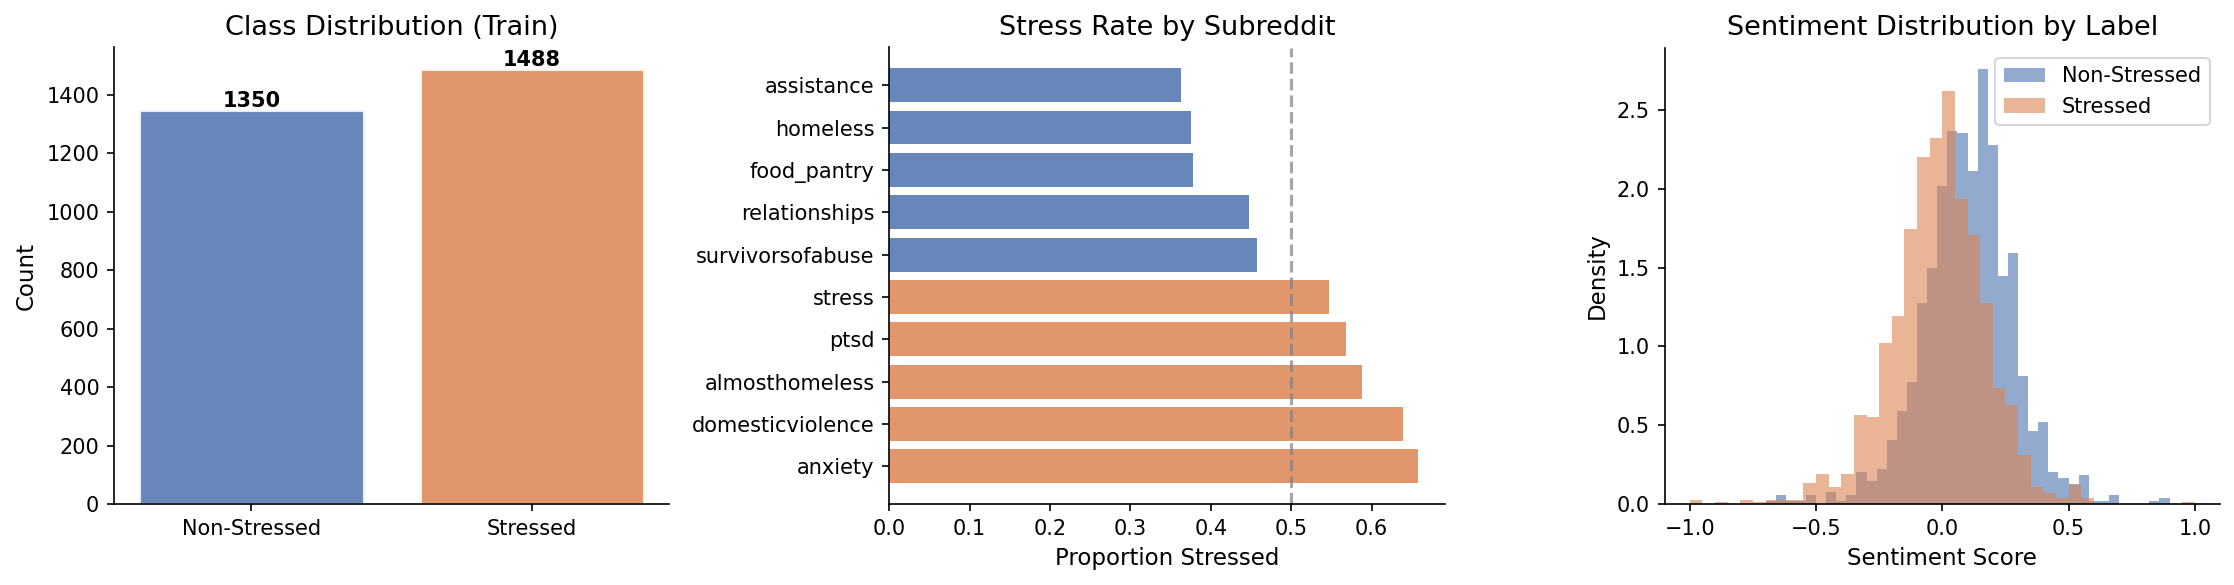

Figure 1: COMPLETED


In [17]:
# Figure 1: Data Exploration

# Data overview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label distribution
ax = axes[0]
counts = train['label'].value_counts()
ax.bar(['Non-Stressed', 'Stressed'], [counts[0], counts[1]],
        color=[NOSTRESS_COLOR, STRESS_COLOR], alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_title('Class Distribution (Train)')
ax.set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

# Stress rate by Subreddit
ax = axes[1]
sub_counts = train.groupby('subreddit')['label'].mean().sort_values(ascending=False)
colors_sub = [STRESS_COLOR if v > 0.5 else NOSTRESS_COLOR for v in sub_counts.values]
ax.barh(sub_counts.index, sub_counts.values, color=colors_sub, alpha=0.85)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
ax.set_title('Stress Rate by Subreddit')
ax.set_xlabel('Proportion Stressed')

# Sentiment distribution
ax = axes[2]
for lbl, color, name in [(0, NOSTRESS_COLOR, 'Non-Stressed'), (1, STRESS_COLOR, 'Stressed')]:
    vals = train[train['label']==lbl]['sentiment'].dropna()
    ax.hist(vals, bins=40, alpha=0.6, color=color, label=name, density=True)
ax.set_title('Sentiment Distribution by Label')
ax.set_xlabel('Sentiment Score')
ax.set_ylabel('Density')
ax.legend()



plt.tight_layout()
plt.savefig('fig1_exploration.png', bbox_inches='tight')
plt.show()

print('Figure 1: COMPLETED')

In [18]:
print(train.groupby('subreddit')['label'].mean().sort_values(ascending=False))

subreddit
anxiety             0.658052
domesticviolence    0.639241
almosthomeless      0.587500
ptsd                0.568493
stress              0.546875
survivorsofabuse    0.457143
relationships       0.447464
food_pantry         0.378378
homeless            0.375000
assistance          0.363322
Name: label, dtype: float64


1. Class distribution is near-balanced with ~52% stressed.
- This minimises the risk of naive majority-class prediction.

2. Subreddits vary markedly in stress rate - communities like `homeless` and `food_pantry` show <50% stressed posts while communities like `ptsd` and `domesticviolence` show >50%.
- Implication: Subreddit identity is potentially a strong prior. Communities like `ptsd` and `domesticviolence` are predominantly stressed while communities like `homeless` and `food_pantry` post about concrete needs rather than emotional states.

3. Stressed posts have a notably lower mean sentiment score.
- Shows a clear negative shift in stressed posts.
- There is substantial overlap --> purely sentiment-based classification would be insufficient

## 1.2 LIWC Feature Analysis

In [19]:
#Figure 2: LIWC Feature Analysis

#Analysing LIWC features first

liwc_cols = [c for c in train.columns if c.startswith('lex_liwc_')]
dal_cols  = [c for c in train.columns if c.startswith('lex_dal_')]
other_num = ['syntax_ari', 'social_karma', 'social_upvote_ratio',
             'social_num_comments', 'syntax_fk_grade', 'sentiment']
feature_cols = liwc_cols + dal_cols + other_num

# Feature difference between classes
diffs = {}
for col in liwc_cols:
    m1 = train[train['label']==1][col].mean()
    m0 = train[train['label']==0][col].mean()
    diffs[col.replace('lex_liwc_', '')] = m1 - m0

diffs_s = pd.Series(diffs).sort_values()

print('Top LIWC features HIGHER in stressed posts:')
print(diffs_s.tail(8))
print('\nTop LIWC features LOWER in stressed posts:')
print(diffs_s.head(8))

Top LIWC features HIGHER in stressed posts:
pronoun          2.075300
focuspresent     2.108180
negemo           2.347070
Dic              2.563784
function         3.250429
i                3.731040
WC               6.504128
Authentic       18.121137
dtype: float64

Top LIWC features LOWER in stressed posts:
Tone          -30.843313
Clout         -25.535724
Analytic      -13.146843
social         -3.260626
AllPunc        -2.148875
OtherP         -1.580318
posemo         -1.377107
affiliation    -1.032248
dtype: float64


*The numbers represent the mean difference between stressed and non-stressed posts for each LIWC feature. E.g. On average, stressed posts use 3.73% more "I" words than non-stressed posts. The more positive the number, the more that feature leans toward stressed posts.

## 1.3 Plot: Feature Differences

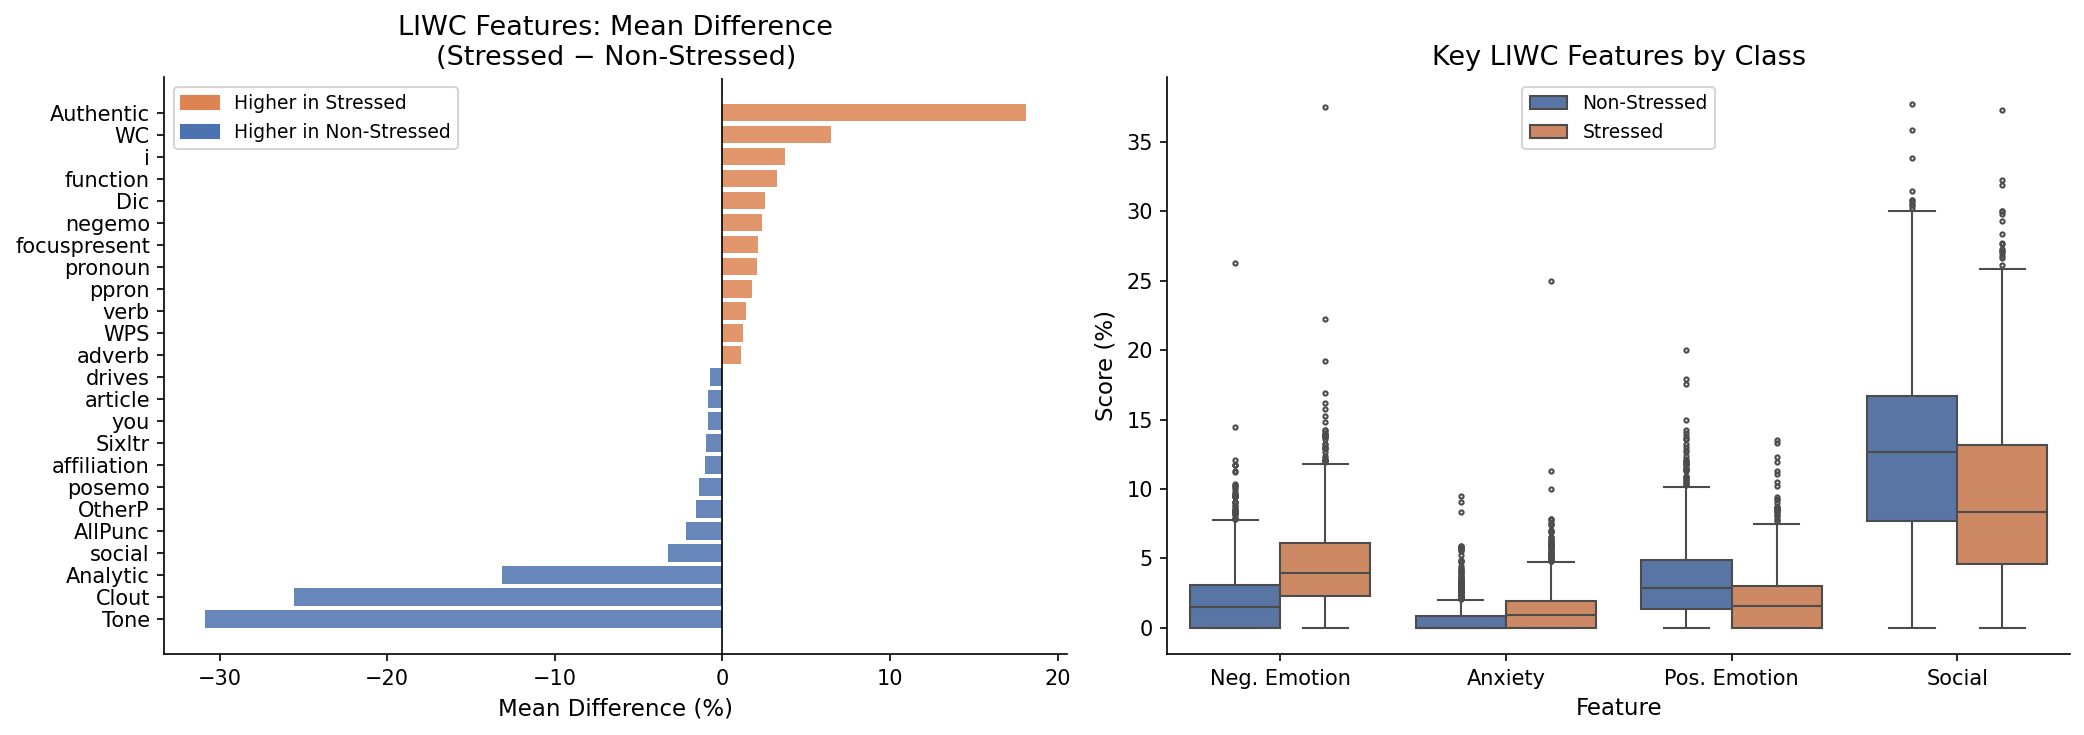

Figure 2: COMPLETED


In [20]:
#Plotting the differences

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_n = 12
combined = pd.concat([diffs_s.head(top_n), diffs_s.tail(top_n)])

ax = axes[0]
colors_bar = [NOSTRESS_COLOR if v < 0 else STRESS_COLOR for v in combined.values]
ax.barh(combined.index, combined.values, color=colors_bar, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('LIWC Features: Mean Difference\n(Stressed − Non-Stressed)')
ax.set_xlabel('Mean Difference (%)')
patch1 = mpatches.Patch(color=STRESS_COLOR, label='Higher in Stressed')
patch2 = mpatches.Patch(color=NOSTRESS_COLOR, label='Higher in Non-Stressed')
ax.legend(handles=[patch1, patch2], fontsize=9)

ax = axes[1]
key_feats = ['lex_liwc_negemo', 'lex_liwc_anx', 'lex_liwc_posemo', 'lex_liwc_social']
labels_map = {'lex_liwc_negemo': 'Neg. Emotion', 'lex_liwc_anx': 'Anxiety',
              'lex_liwc_posemo': 'Pos. Emotion', 'lex_liwc_social': 'Social'}
data_plot, labels_plot, hues_plot = [], [], []
for f in key_feats:
    for lbl in [0, 1]:
        vals = train[train['label']==lbl][f].dropna().values
        data_plot.extend(vals)
        labels_plot.extend([labels_map[f]] * len(vals))
        hues_plot.extend(['Non-Stressed' if lbl==0 else 'Stressed'] * len(vals))

plot_df = pd.DataFrame({'Feature': labels_plot, 'Value': data_plot, 'Class': hues_plot})
palette = {'Non-Stressed': NOSTRESS_COLOR, 'Stressed': STRESS_COLOR}
sns.boxplot(data=plot_df, x='Feature', y='Value', hue='Class', ax=ax,
            palette=palette, flierprops={'markersize': 2}, linewidth=1)
ax.set_title('Key LIWC Features by Class')
ax.set_ylabel('Score (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig2_liwc.png', bbox_inches='tight')
plt.show()

print('Figure 2: COMPLETED')

Features like negative emotion (`negemo`) and first-person pronoun usage (`i`) are shown higher in stressed posts, while features like `Tone`, `Clout` and positive emotion (`posemo`) are shown higher in non-stressed posts.

The boxplots confirm that these differences between stressed and non-stressed posts hold across the distribution for negative emotion (`Neg. Emotion`), `Anxiety`, positive emotion (`Pos. Emotion`) and `Social` words. However, substantial overlap exists --> indicates these features alone are insufficient for reliable classification.

## 2. Modelling

Chosen models:

| Model | Features Used | Motivation |
|---|---|---|
| Logistic Regression | Pre-computed LIWC + DAL + social features | Fast, interpretable baseline; coefficients reveal which psychological dimensions predict stress |
| Random Forest | Same tabular feature set | Captures non-linear interactions between LIWC categories (e.g. high `anxiety` + low `social` = more stressed) |
| TF-IDF + Logistic Regression | Raw text bag-of-words (n-grams 1-2) | Captures specific words/phrases the LIWC dictionary may miss; complementary to psycholinguistic features |

Other models considered (but not used):
1. **BERT**
- Would likely yield the highest F1 score but comes with significant interpretability costs
- NOTE: Our primary goal is to select the best clinical deployment tool that is explainable to clinicians and policymakers
- LIWC-based models offer direct mappings to validated psychological constructs, making them more suitable for clinical sense-making

Other considerations:
1. **Class imbalance handling**
- The dataset is near balanced (48% vs 52%)
- Use `class_weight = 'balanced'` as a conservative measure rather than aggressive resampling

## 2.1 Feature Engineering

In [21]:
X_train_feat = train[feature_cols].fillna(0)
X_test_feat  = test[feature_cols].fillna(0)
y_train = train['label']
y_test  = test['label']

# Scale for LR
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train_feat)
X_te_s = scaler.transform(X_test_feat)

# TF-IDF text features
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3)
X_tr_tfidf = tfidf.fit_transform(train['text'].fillna(''))
X_te_tfidf = tfidf.transform(test['text'].fillna(''))

print(f'LIWC feature matrix: {X_train_feat.shape}')
print(f'TF-IDF feature matrix: {X_tr_tfidf.shape}')

LIWC feature matrix: (2838, 108)
TF-IDF feature matrix: (2838, 10000)


## 2.2 Model Training

### 2.2.1 Logistic Regression

In [22]:
# Model 1: Logistic Regression (LIWC features)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X_tr_s, y_train)
lr_pred = lr.predict(X_te_s)
lr_prob = lr.predict_proba(X_te_s)[:,1]
lr_f1  = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)
print(f'[LR - LIWC]  F1={lr_f1:.4f}  AUC={lr_auc:.4f}')

[LR - LIWC]  F1=0.7583  AUC=0.8332


### 2.2.2 Random Forest

In [47]:
# Model 2: Random Forest (LIWC features)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             random_state=RANDOM_STATE, max_depth=12, min_samples_leaf=5)
rf.fit(X_train_feat, y_train)
rf_pred = rf.predict(X_test_feat)
rf_prob = rf.predict_proba(X_test_feat)[:,1]
rf_f1  = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)
print(f'[RF - LIWC]  F1={rf_f1:.4f}  AUC={rf_auc:.4f}')

[RF - LIWC]  F1=0.7592  AUC=0.8339


### 2.2.3 TF-IDF + Logistic Regression

In [48]:
# Model 3: TF-IDF + Logistic Regression

lr_text = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr_text.fit(X_tr_tfidf, y_train)
txt_pred = lr_text.predict(X_te_tfidf)
txt_prob = lr_text.predict_proba(X_te_tfidf)[:,1]
txt_f1  = f1_score(y_test, txt_pred)
txt_auc = roc_auc_score(y_test, txt_prob)
print(f'[LR - TF-IDF] F1={txt_f1:.4f}  AUC={txt_auc:.4f}')

[LR - TF-IDF] F1=0.7388  AUC=0.8184


## 2.3 Model Performance Analysis

**Results**

| Model | F1 Score | AUC Score |
|---|---|---|
| Logistic Regression | 0.7583 | 0.8332 |
| **Random Forest** | **0.7592** | **0.8339** |
| TF-IDF + Logistic Regression | 0.7388 | 0.8184 |

Based on the results above, we can naively conclude that Random Forest is the best model.

## 2.4 Cross-Validation
Rationale: To estimate how well model generalises to unseen data, using only the training set (we do not know if the score was 'lucky' or actually representative)
- Ensures **model reliability** - mean & standard deviation inform if performance is consistent (low std = stable model) or variable (high std = unstable) and how good model is on average
- **Hyperparameter tuning** - different model settings can be compared using CV score without touching the test set, keeping the test set truly unseen until final evaluation --> prevents data leakage

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model, Xtr, name in [
    (lr,      X_tr_s,      'LR (LIWC)'),
    (rf,      X_train_feat, 'RF (LIWC)'),
    (lr_text, X_tr_tfidf,  'LR (TF-IDF)'),
]:
    scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='f1')
    print(f'{name:20s}  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}')

LR (LIWC)             CV F1 = 0.7760 ± 0.0148
RF (LIWC)             CV F1 = 0.7657 ± 0.0092
LR (TF-IDF)           CV F1 = 0.7628 ± 0.0142


**Results**

| Model | F1 Score |
|---|---|
| Logistic Regression | 0.7760 ± 0.0148 | 
| **Random Forest** | **0.7657 ± 0.0092** | 
| TF-IDF + Logistic Regression | 0.7628 ± 0.0142 | 

The results are consistent with the initial findings. Random Forest is the best model.

## 2.5 Plot: Model Comparison

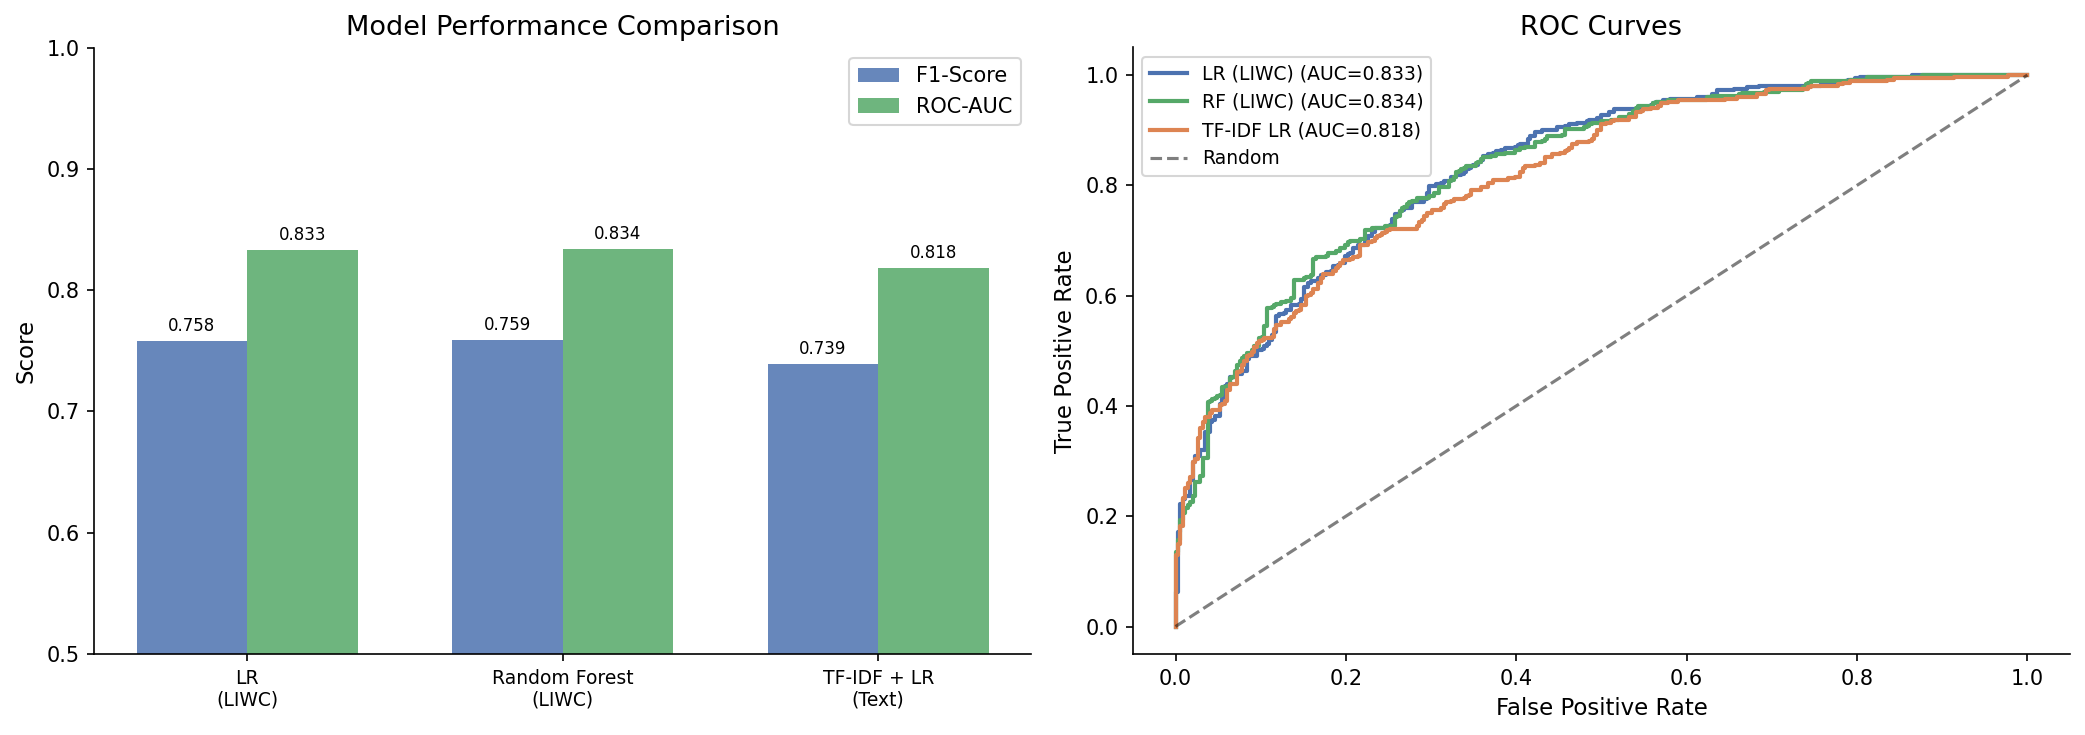

In [31]:
# Figure 3a: Model Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = ['LR\n(LIWC)', 'Random Forest\n(LIWC)', 'TF-IDF + LR\n(Text)']
f1s  = [lr_f1,  rf_f1,  txt_f1]
aucs = [lr_auc, rf_auc, txt_auc]

ax = axes[0]
x = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x - w/2, f1s,  w, label='F1-Score', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + w/2, aucs, w, label='ROC-AUC', color='#55A868', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
for pred_p, name, color in [(lr_prob, 'LR (LIWC)', '#4C72B0'),
                              (rf_prob, 'RF (LIWC)', '#55A868'),
                              (txt_prob, 'TF-IDF LR', '#DD8452')]:
    fpr, tpr, _ = roc_curve(y_test, pred_p)
    auc = roc_auc_score(y_test, pred_p)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})', linewidth=2)
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig3_model_comparison.png', bbox_inches='tight')
plt.show()

- All 3 models achieve similar F1 (~0.73-0.76) and AUC (~0.81-0.84).
- Random Forest slightly outperforms on F1. 
- ROC curves show the models hvae near-identical discrimination ability*, suggesting the LIWC features capture most of the signal available from raw text.

*Discrimination ability: how well model can distinguish between the 2 classes - stressed vs non-stressed

## 2.6 Model Selection

Conclusion: **Random Forest** is the best model out of the 3.

## 2.7 Model Testing

In [39]:
print('Best Model: Random Forest (LIWC Features)')
print(classification_report(y_test, rf_pred, target_names=['Non-Stressed', 'Stressed']))

Best Model: Random Forest (LIWC Features)
              precision    recall  f1-score   support

Non-Stressed       0.75      0.70      0.72       346
    Stressed       0.73      0.79      0.76       369

    accuracy                           0.74       715
   macro avg       0.74      0.74      0.74       715
weighted avg       0.74      0.74      0.74       715



### 2.7.1 Confusion Matrix (Random Forest)

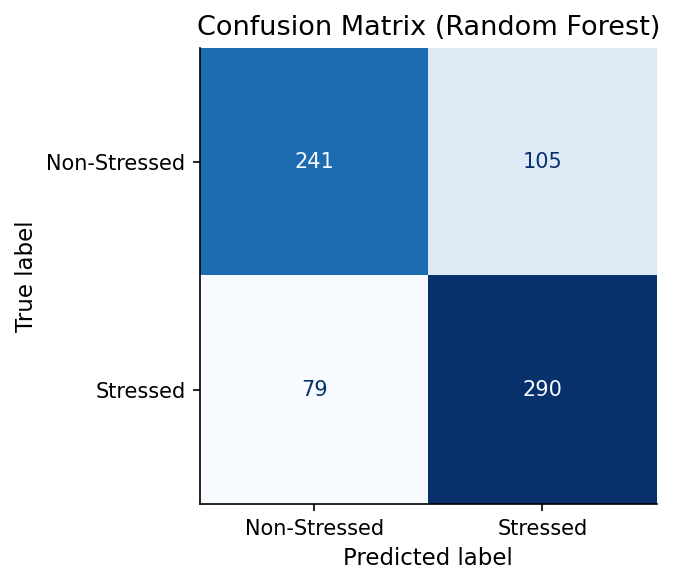

In [40]:
# Figure 3b: Confusion Matrix (Random Forest)

fig, ax = plt.subplots(figsize=(5, 4))

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Stressed', 'Stressed'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Random Forest)')

plt.tight_layout()
plt.savefig('fig3b_confusion_matrix.png', bbox_inches='tight')
plt.show()

**True Positive Rate (TPR) = 78.6%**
- 7 in 10 actually stressed posts are correctly predicted as stressed.

**False Positive Rate (FPR) = 30.3%**
- 3 in 10 actually non-stressed posts are incorrectly predicted as stressed.
- This could potentially lead to inefficiency due to misallocation of resources and manpower.

**False Negative Rate (FNR) = 21.4%**
- 1 in 5 actually stressed posts are incorrectly predicted as non-stressed.

**True Negative Rate (TNR) = 69.7%**
- 3 in 5 actually non-stressed posts are correctly predicted as non-stressed.

 <br>

**Implication:** 
- The model is better at catching stressed posts (78.6%) than correctly clearing non-stressed posts (69.7%). 
- Although the FNR is relatively low, it is critical to reduce it further. A False Negative in this context means a genuinely distressed individual goes undetected and unsupported. The cost of missing a stressed person can be severe - delayed intervention, escalating distress, or in extreme cases, self-harm. With a FNR of 21.4%, approximately 1 in 5 stressed users would be missed by the model if used as a standalone decision system, representing a meaningful clinical risk. This issue will be discussed further in Section 3.2 due to its importance.

## 3. Analyses

### 3.1 Analysis #1: Which subreddit is easiest to predict?

Different communities have very different base rates of stress and different types of discourse. For example, a subreddit like `ptsd` is about an inherently traumatic experience and users tend to write in consistently stress-marked language such as fear, intrusive thoughts and hyperarousal cues. A subreddit like `relationships`, on the other hand, is more ambiguous. Posts can be seeking advice without being emotionally distressed or describing positive milestones. This creates a harder classification boundary. The main objective is to determine which subreddit is the easiest to predict, and the reason(s) why.

In [41]:
test_df = test.copy()
test_df['pred'] = rf_pred
test_df['prob'] = rf_prob
test_df['correct'] = (test_df['pred'] == test_df['label']).astype(int)

sub_perf = []
for sub in test_df['subreddit'].unique():
    sub_data = test_df[test_df['subreddit'] == sub]
    if len(sub_data) < 5: continue
    f1 = f1_score(sub_data['label'], sub_data['pred'], zero_division=0)
    sub_perf.append({'subreddit': sub, 'f1': f1, 'n': len(sub_data),
                     'stress_rate': sub_data['label'].mean()})
    
sub_perf_df = pd.DataFrame(sub_perf).sort_values('f1', ascending=False)

print(sub_perf_df.to_string(index=False))

       subreddit       f1   n  stress_rate
            ptsd 0.855491 127     0.645669
          stress 0.842105  14     0.714286
domesticviolence 0.826087  72     0.652778
         anxiety 0.822917 147     0.578231
     food_pantry 0.800000   6     0.500000
      assistance 0.702703  66     0.318182
survivorsofabuse 0.695652  70     0.442857
  almosthomeless 0.666667  19     0.631579
        homeless 0.594595  52     0.346154
   relationships 0.571429 142     0.422535


### 3.1.1 Plot: Results

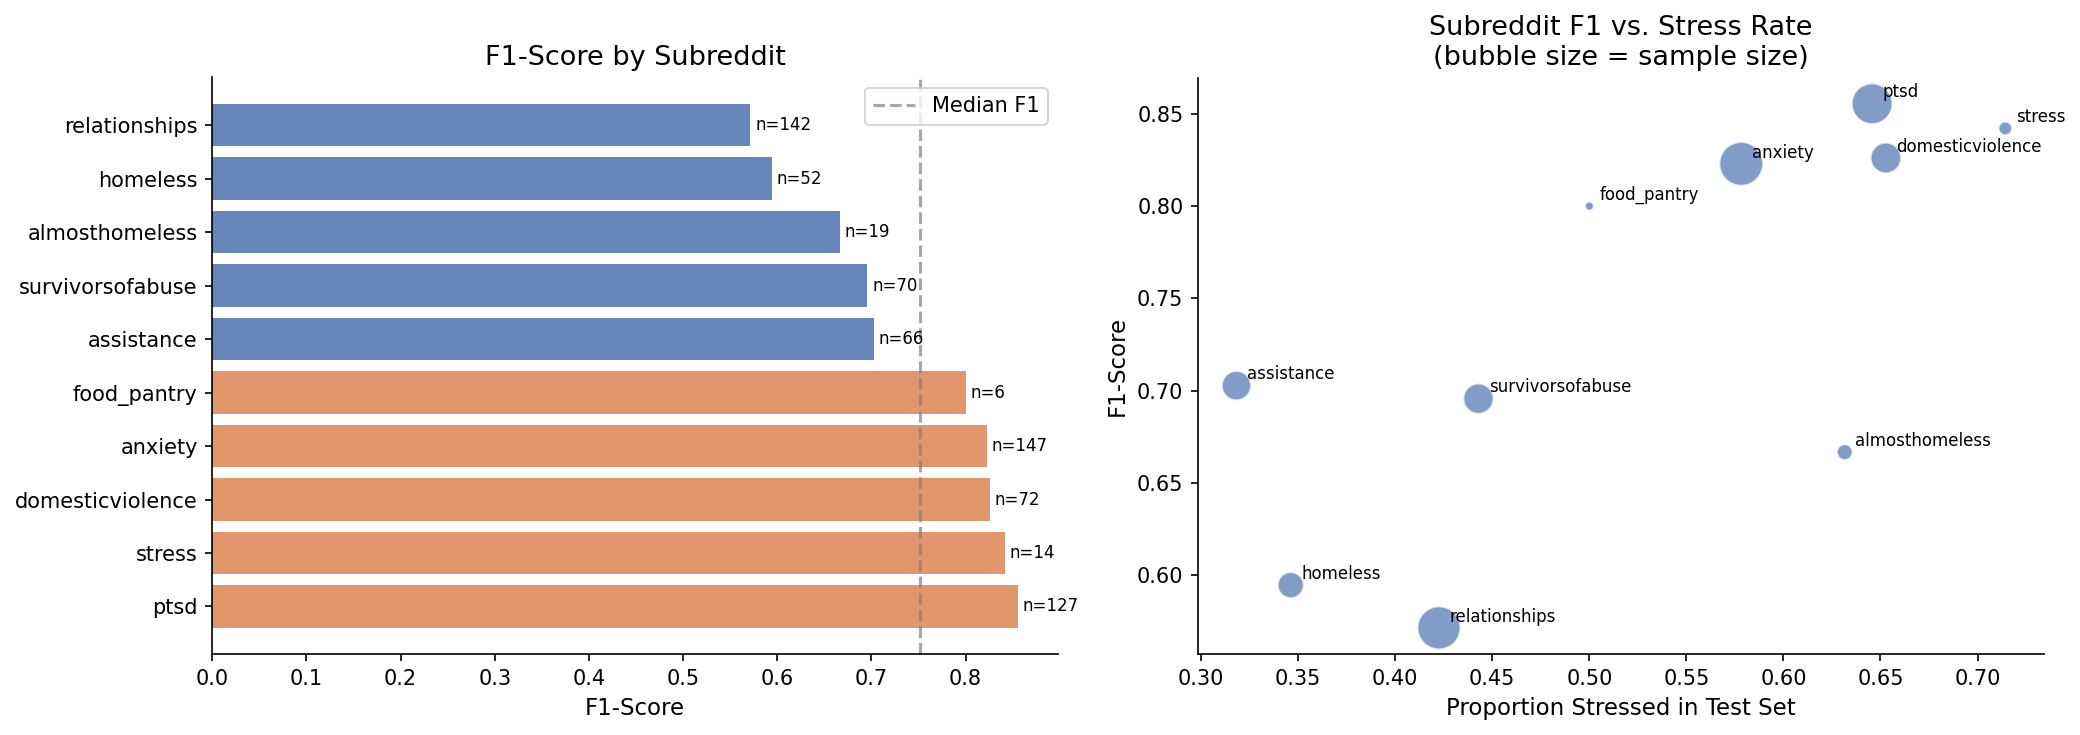

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors_sub2 = [STRESS_COLOR if f > sub_perf_df['f1'].median() else NOSTRESS_COLOR
               for f in sub_perf_df['f1']]
bars = ax.barh(sub_perf_df['subreddit'], sub_perf_df['f1'], color=colors_sub2, alpha=0.85)
ax.axvline(sub_perf_df['f1'].median(), color='gray', linestyle='--', alpha=0.7, label='Median F1')
ax.set_title('F1-Score by Subreddit')
ax.set_xlabel('F1-Score')
ax.legend()
for bar, n in zip(bars, sub_perf_df['n']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={n}', va='center', fontsize=8)
    
ax = axes[1]
ax.scatter(sub_perf_df['stress_rate'], sub_perf_df['f1'],
           s=sub_perf_df['n']*3, alpha=0.7, color='#4C72B0', edgecolors='white')
for _, row in sub_perf_df.iterrows():
    ax.annotate(row['subreddit'], (row['stress_rate'], row['f1']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)
ax.set_xlabel('Proportion Stressed in Test Set')
ax.set_ylabel('F1-Score')
ax.set_title('Subreddit F1 vs. Stress Rate\n(bubble size = sample size)')

plt.tight_layout()
plt.savefig('fig4_subreddit.png', bbox_inches='tight')
plt.show()

### 3.1.2 Conclusion

Subreddits with clearer stress-related topic focus (`anxiety`, `domesticviolence`, `stress` and `ptsd`) yield F1 > 0.81. Relationship and resource-seeking subreddits are harder to predict. There is a weak positive trend: higher stress rates correlate with better F1 score, suggesting that topically coherent communities are easier to classify.

**Implication**: The model performs best on subreddits where stress is a defining topic of the community. For instance, `ptsd`: F1 = 0.855; `anxiety`: F1 = 0.823. These communities have a consistent vocabulary of distress. The `relationships` subreddit is the hardest to predict (F1 = 0.571). Users seek advice on interpersonal dynamics that may or may not reflect personal distress and non-stressed posts can contain emotionally charged language such as describing a partner's behaviour (e.g. "I heard her crying uncontrollably and shaking and screaming" --> contains highly negative, emotionally charged language but the annotator labelled it `non-stressed` because the user is describing someone else's behaviour rather than expressing their own distress. The model, however, sees the negative emotion words and predicts `stressed`.)

This has important deployment implications: **a tool calibrated on ptsd/anxiety communities may perform poorly when deployed on general forums**. Nonetheless, the model is still useful for triaging posts within known communities such as platforms specifically dedicated to mental health (e.g. anxiety forums, PTSD support groups). Additionally, even in harder communities, the model's probability score `rf_prob` still provides a useful ranking singal. A moderator reviewing 100 posts could prioritise the top 20 by predicted stress probability and still catch more distressed users than random review.

### 3.2 Analysis #2: Understanding where model fails

Understanding where the model fails is clinically more important than the average F1 score. In a mental health context, **False Negatives** (missing a stressed person) are particularly dangerous. They present a failure to provide support to someone who needs it. The cost of such errors is substantial, with potentially critical consequences. **False Positives** are less dangerous but can cause unnecessary burden on moderators or welfare resources. As resources are scarced, this may lead to inefficiencies and manpower could otherwise be directed toward individuals in greater need.

In [43]:
test_df['fp'] = ((test_df['pred']==1) & (test_df['label']==0)).astype(int)
test_df['fn'] = ((test_df['pred']==0) & (test_df['label']==1)).astype(int)

total_fp = test_df['fp'].sum()
total_fn = test_df['fn'].sum()

print(f'Total False Positives: {total_fp} ({total_fp/len(test_df)*100:.1f}% of test set)')
print(f'Total False Negatives: {total_fn} ({total_fn/len(test_df)*100:.1f}% of test set)')
print(f'\nHigh-confidence errors (>70% confident wrong):')
high_conf_wrong = test_df[(test_df['correct']==0)]
high_conf_wrong['conf_wrong'] = high_conf_wrong.apply(
    lambda r: r['prob'] if r['pred']==1 else 1-r['prob'], axis=1)
print(high_conf_wrong[high_conf_wrong['conf_wrong']>0.7][['subreddit','label','pred','conf_wrong']].head(10))

Total False Positives: 105 (14.7% of test set)
Total False Negatives: 79 (11.0% of test set)

High-confidence errors (>70% confident wrong):
         subreddit  label  pred  conf_wrong
22         anxiety      0     1    0.700572
50   relationships      0     1    0.863311
56            ptsd      0     1    0.702651
129        anxiety      0     1    0.723743
170           ptsd      0     1    0.799749
173  relationships      1     0    0.701443
174  relationships      1     0    0.752851
175  relationships      1     0    0.792609
178        anxiety      0     1    0.738744
181  relationships      1     0    0.780767


### 3.2.1 Plot: Results

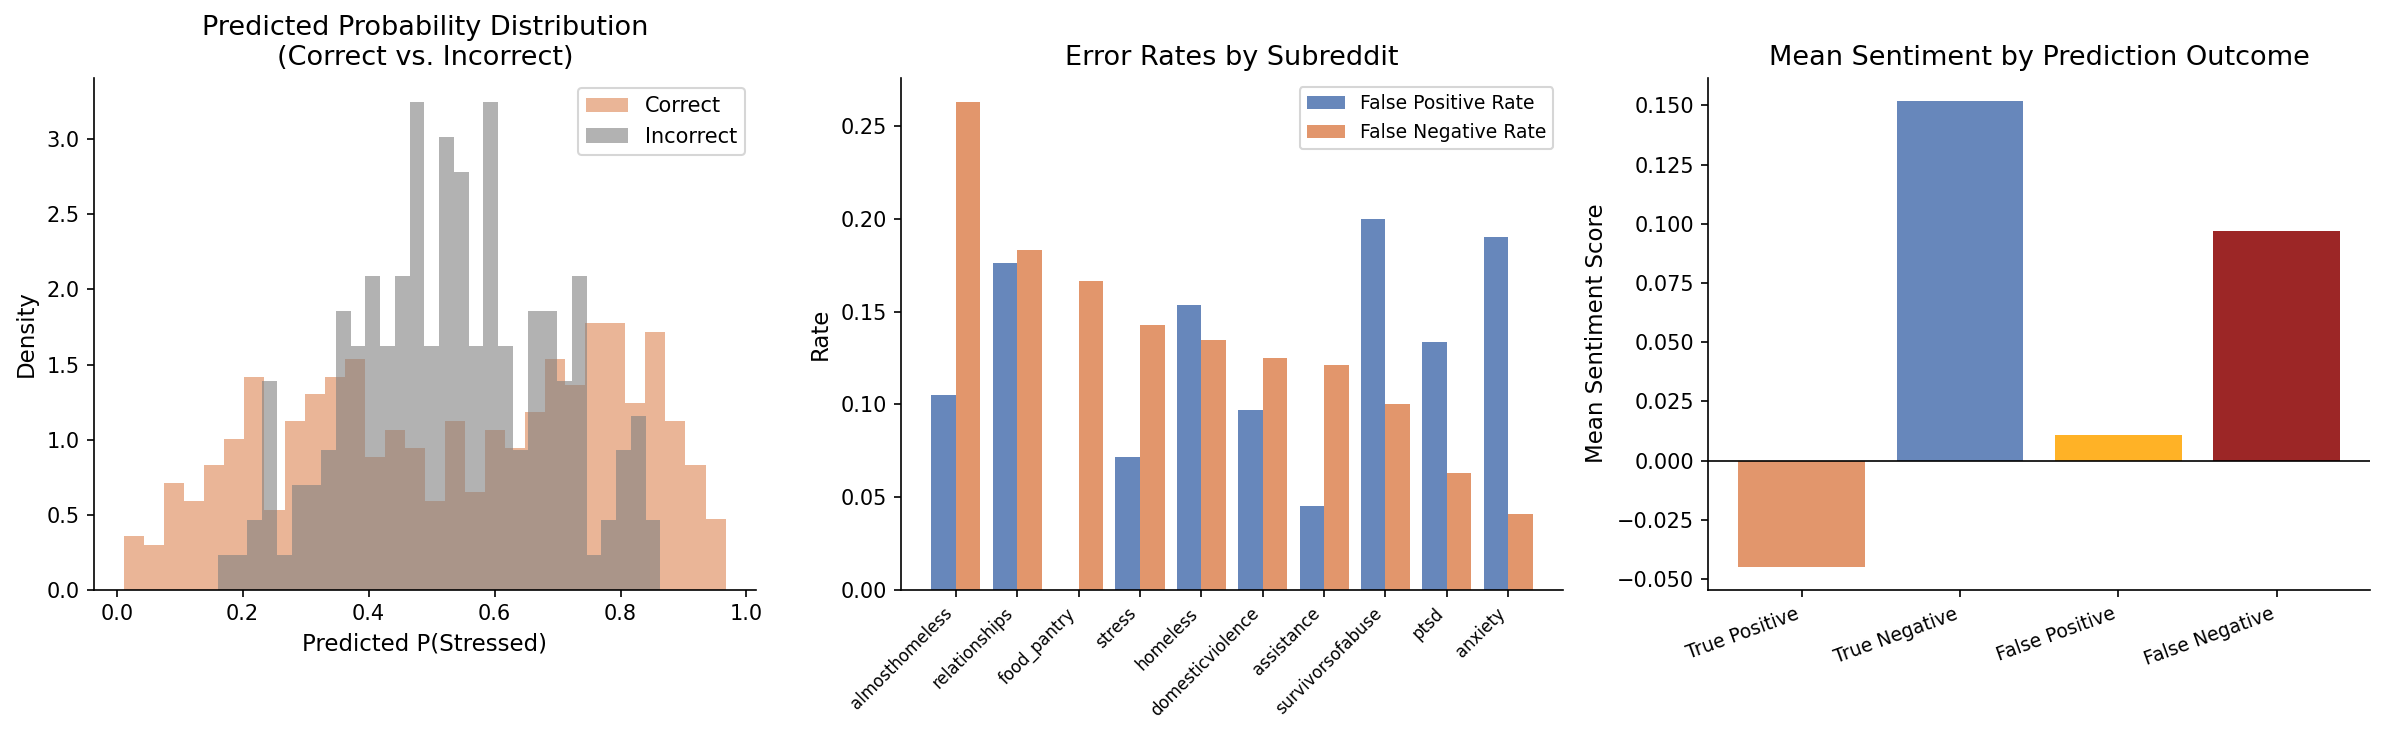

In [44]:
# Figure 5: Model Failure Analysis

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for lbl, color, name in [(1, STRESS_COLOR, 'Correct'), (0, 'gray', 'Incorrect')]:
    subset = test_df[test_df['correct']==lbl]['prob']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=name, density=True)
ax.set_title('Predicted Probability Distribution\n(Correct vs. Incorrect)')
ax.set_xlabel('Predicted P(Stressed)')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
err_by_sub = test_df.groupby('subreddit').agg(
    FP=('fp','sum'), FN=('fn','sum'), N=('label','count')).reset_index()
err_by_sub['FP_rate'] = err_by_sub['FP'] / err_by_sub['N']
err_by_sub['FN_rate'] = err_by_sub['FN'] / err_by_sub['N']
err_by_sub = err_by_sub.sort_values('FN_rate', ascending=False)
x_pos = np.arange(len(err_by_sub))
ax.bar(x_pos - 0.2, err_by_sub['FP_rate'], 0.4, label='False Positive Rate',
       color=NOSTRESS_COLOR, alpha=0.85)
ax.bar(x_pos + 0.2, err_by_sub['FN_rate'], 0.4, label='False Negative Rate',
       color=STRESS_COLOR, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(err_by_sub['subreddit'], rotation=45, ha='right', fontsize=8)
ax.set_title('Error Rates by Subreddit')
ax.set_ylabel('Rate')
ax.legend(fontsize=9)

ax = axes[2]
categories = ['True Positive', 'True Negative', 'False Positive', 'False Negative']
masks = [
    (test_df['label']==1) & (test_df['pred']==1),
    (test_df['label']==0) & (test_df['pred']==0),
    (test_df['label']==0) & (test_df['pred']==1),
    (test_df['label']==1) & (test_df['pred']==0),
]
sent_vals = [test_df[m]['sentiment'].mean() for m in masks]
colors_err = [STRESS_COLOR, NOSTRESS_COLOR, '#FFA500', '#8B0000']
ax.bar(categories, sent_vals, color=colors_err, alpha=0.85)
ax.set_title('Mean Sentiment by Prediction Outcome')
ax.set_ylabel('Mean Sentiment Score')
ax.set_xticklabels(categories, rotation=20, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig5_failure.png', bbox_inches='tight')
plt.show()

Incorrect predictions cluster around P(Stressed) ≈ 0.5, indicating model uncertainty in borderline cases. The `relationships` subreddit has the highest False Negative rate. Stressed users in the community write in ways that resemble non-stressed advice-seeking. False Positives have a distinctive pattern: negative sentiment similar to true positives, suggesting the model conflates emotionally intense but non-stressed posts with stressed ones.

In [45]:
print('False Negatives: Missed Stress (most dangerous)')
fn_cases = test_df[test_df['fn']==1].sort_values('prob').head(3)
for _, row in fn_cases.iterrows():
    print(f"Sub: {row['subreddit']} | P(stress)={row['prob']:.2f}")
    print(f"Text: {str(row['text'])[:300]}")
    print()

print('False Positives: Wrong Alarm')
fp_cases = test_df[test_df['fp']==1].sort_values('prob', ascending=False).head(3)
for _, row in fp_cases.iterrows():
    print(f"Sub: {row['subreddit']} | P(stress)={row['prob']:.2f}")
    print(f"Text: {str(row['text'])[:300]}")
    print()

False Negatives: Missed Stress (most dangerous)
Sub: relationships | P(stress)=0.16
Text: She told me that things had to go back to where we were before we ever went to the concert. I agreed, and stopped talking to her aside from professional responsibilities. NOW... in that period of time since two MAJOR things have happened. 1. Her mother was diagnosed with cancer.

Sub: relationships | P(stress)=0.21
Text: We met about 2.5 years ago, both somewhat fresh off our respective divorces. I felt we had a real connection, we fell for each other hard, dated (eventually lived together) for a little less than a year before she got pregnant. We were both really happy as we had both talked about wanting children -

Sub: relationships | P(stress)=0.21
Text: Now six weeks ago, I was asked to contribute $250 to the household, great no issue. Now suddenly (this happened in the space of an hour yesterday and was never discussed with me), my rent has doubled to $500, and my boyfriends tripled to $700.

### 3.2.2 Conclusion

**Key Observations & Implications**:

1. **Implicit stress (False Negatives in `relationships`)**: Users describe stressful situations using factual, narrative language wihtout explicit emotional markers. The LIWC model is calibrated to detect expressed emotion, not implied stress.

2. **Emotional intensity =/= stress (False Positives in `relationships`)**: Posts expressing strong dissatisfaction or frustration (high `negemo`, high `anger`) but that are labelled `non-stressed`. Model over-fires on intense emotional language (user could be venting constructively).

3. **Recovery narrative (False Positives in `ptsd`/`anxiety`)**: Emotionally loaded text that the model reads as current distress but is actually annotated as non-stressed.

### 3.3 Analysis #3: Model interpretability - What features signal stress?

For a tool to be trusted by clinical users (e.g. forum moderators, mental health counsellors), it must be explainable. Here, I examine both RF feature importances (which LIWC dimensions are relevant) and LR text coefficients (which specific words/phrases are relevant).

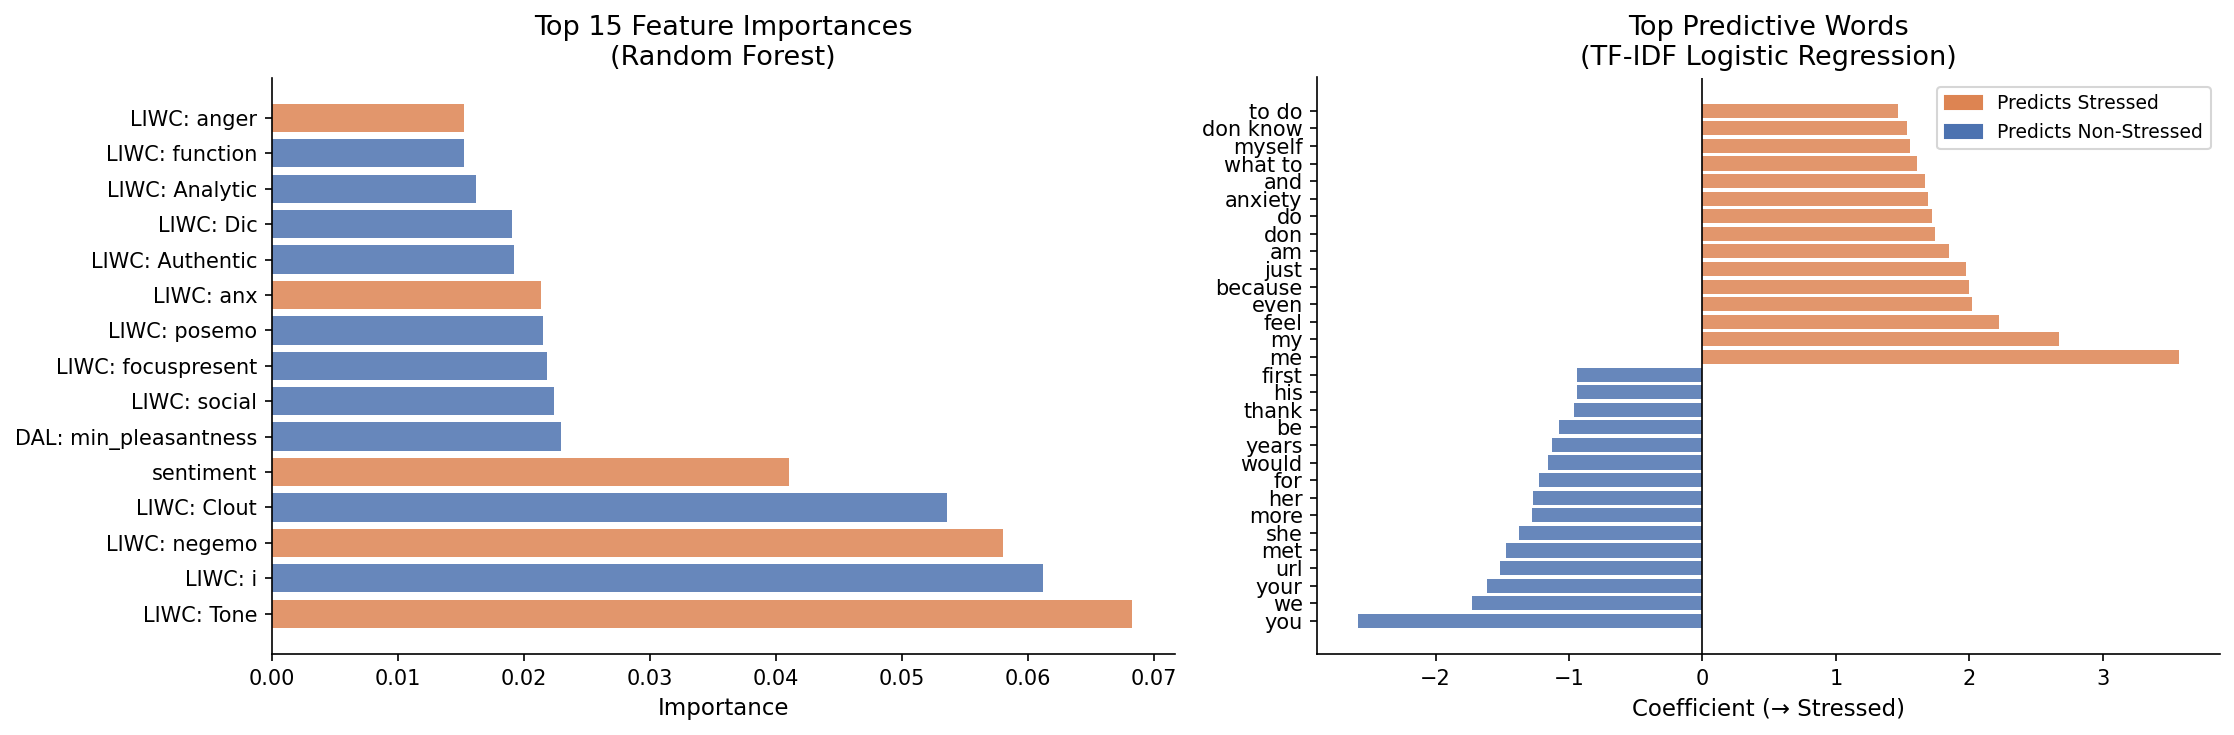

In [46]:
# Figure 6: Interpretability Analysis (Feature Importance)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols)
top_feats = feat_imp.nlargest(15)
top_feats.index = [i.replace('lex_liwc_', 'LIWC: ').replace('lex_dal_', 'DAL: ')
                   .replace('syntax_', 'Syntax: ').replace('social_', 'Social: ') for i in top_feats.index]
colors_imp = ['#DD8452' if any(k in i for k in ['negemo','anx','sad','anger','Tone','sentiment'])
              else '#4C72B0' for i in top_feats.index]
ax.barh(top_feats.index, top_feats.values, color=colors_imp, alpha=0.85)
ax.set_title('Top 15 Feature Importances\n(Random Forest)')
ax.set_xlabel('Importance')

ax = axes[1]
coef = lr_text.coef_[0]
vocab = np.array(tfidf.get_feature_names_out())
top_pos = np.argsort(coef)[-15:][::-1]
top_neg = np.argsort(coef)[:15]
combined_idx = np.concatenate([top_neg, top_pos])
combined_coef = coef[combined_idx]
combined_words = vocab[combined_idx]
colors_coef = [NOSTRESS_COLOR if c < 0 else STRESS_COLOR for c in combined_coef]
ax.barh(combined_words, combined_coef, color=colors_coef, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top Predictive Words\n(TF-IDF Logistic Regression)')
ax.set_xlabel('Coefficient (→ Stressed)')
patch1 = mpatches.Patch(color=STRESS_COLOR, label='Predicts Stressed')
patch2 = mpatches.Patch(color=NOSTRESS_COLOR, label='Predicts Non-Stressed')
ax.legend(handles=[patch1, patch2], fontsize=9)

plt.tight_layout()
plt.savefig('fig6_interpretability.png', bbox_inches='tight')
plt.show()

### 3.3.1 Conclusion
Left: `sentiment` score, `LIWC: Tone` and negative emotion (`LIWC: negemo`) are the most discriminative RF features.

Right: TF-IDF shows specific words. First-person, inward-focused language (`me`, `i`, `feel`) and phrases like `don know` and `what to do` that suggest helplessness and confusion appear as stressed words. The non-stressed words are more other-directed (`you`, `we`, `she`, `his`) and words like `thank` and `url` potentially suggest resource-seeking and gratitude typical of non-stressed assitance-seeking or follow-up posts that convey positive progress.

Note: This is highly consistent with the LIWC finding that stressed posts have higher `i` pronoun usage and lower `social` scores. Both point to the same underlying pattern of self-focus under stress versus other-focus in non-stressed posts. 

## 4 Clinical Ethics & Deployment Considerations

### 4.1 Potential use case: Let's Talk by Mindline forum monitoring
In Singapore, platforms like Let's Talk by Mindline host anonymous support forums. A stress-detection system could help moderators triage posts requiring urgent human attention, particularly for late-night posts when real-time human coverage may be low.


### 4.2 Risk of False Negatives
A False Negative (classifying a distressed person as non-stressed) means a post would go unreviewed. In a mental health context, this is the more dangerous error. My best model has a FN rate of ~21.4% overall, with it being notably higher in `relationships`-type communities. If deployed on a general forum:
- Posts using narrative, non-emotive lanuage about distressing situations would be systematically missed.
- Users who suppress emotional expression (common in East Asian cultural contexts) would be disproportionately underserved.
- The model should never be used as a replacement for human review. It is only used as a triage signal to prioritise the human reviewer's attention queue. Ultimately, humans are the only ones capable of reading, interpreting and responding to the emotional aspects of things. 

### 4.3 Risk of Automated Surveillance
A False Positive rate of ~30.3% means 1 in 3 non-stressed posts would be flagged. If this triggers unsolicited reach (e.g. welfare phone calls), it could:
- Violate user expectations of anonymity
- Deter users from posting, reducing help-seeking behaviour
- Introduce a chilling effect on free expression in support communities
Additionally, misallocation of resources may also lead to inefficiencies and manpower could have been diverted towards those who actually require support.

### 4.4 Recommended deployment principle
Use the model to rank a moderator's review queue by predicted stress probability (`rf_prob`), not to take autonomous action. The model should be an attention allocation tool, not a decision system.

### 4.5 Bias, Limitations & Generalisability
- The model was trained on specific English-language Reddit communities from 2019. Singapore's mental health discourse may differ in vocabulary, cultural reference, code-swtiching (Singlish, mother tongue borrowings) and contexts.
- The Dreaddit annotation used US-based annotators. Cultural norms around expressing distress may differ significantly.
- Regular retraining with locally-sourced labelled data would be essential.

## 5. Conclusion

This deliverable build and compared 3 stress-detection classifiers on the Dreaddit dataset. The best model, Random Forest on LIWC/DAL psycholinguistic features, achieved an F1 score of 0.7592 and AUC of 0.8339 on the held-out test set, with consistent 5-fold CV performance (F1 = 0.7657 ± 0.0092)

**Key findings:**
1. Subreddit context matters enormously: The model is reliable on communities where stress is topically central like `ptsd` (F1=0.855) but struggles on ambiguous communities like `relationships` (F1=0.571), where stress is expressed implicitly.
2. False Negatives are the clinical risk: The model systematically misses stress when it is expressed narratively wihtout explicit emotional markers. This is a limitation that must be communicated to any clinical deployer as the cost can be significant.
3. Interpretability strengthens clincal trust: LIWC features align with established psychological theory, making the model's reasoning *legible to non-technical stakeholders.
4. Automated surveillance is a real risk: The model should only serve as a triage prioritisation tool and never as an autonomous decision system. This is to preserve user trust, forum safety and efficient allocation of resources.

Future work should explore domain-adaptive fine-tuning of language models on locally-sourced data and incorporate longitudinal signals (e.g. change in posting behaviour over time) which may capture stress trajectories that single-post classifiers cannot.

*Compare this to a BERT model which might say: "This post was flagged because attention head 7 activated strongly on tokens 3, 8, and 14"